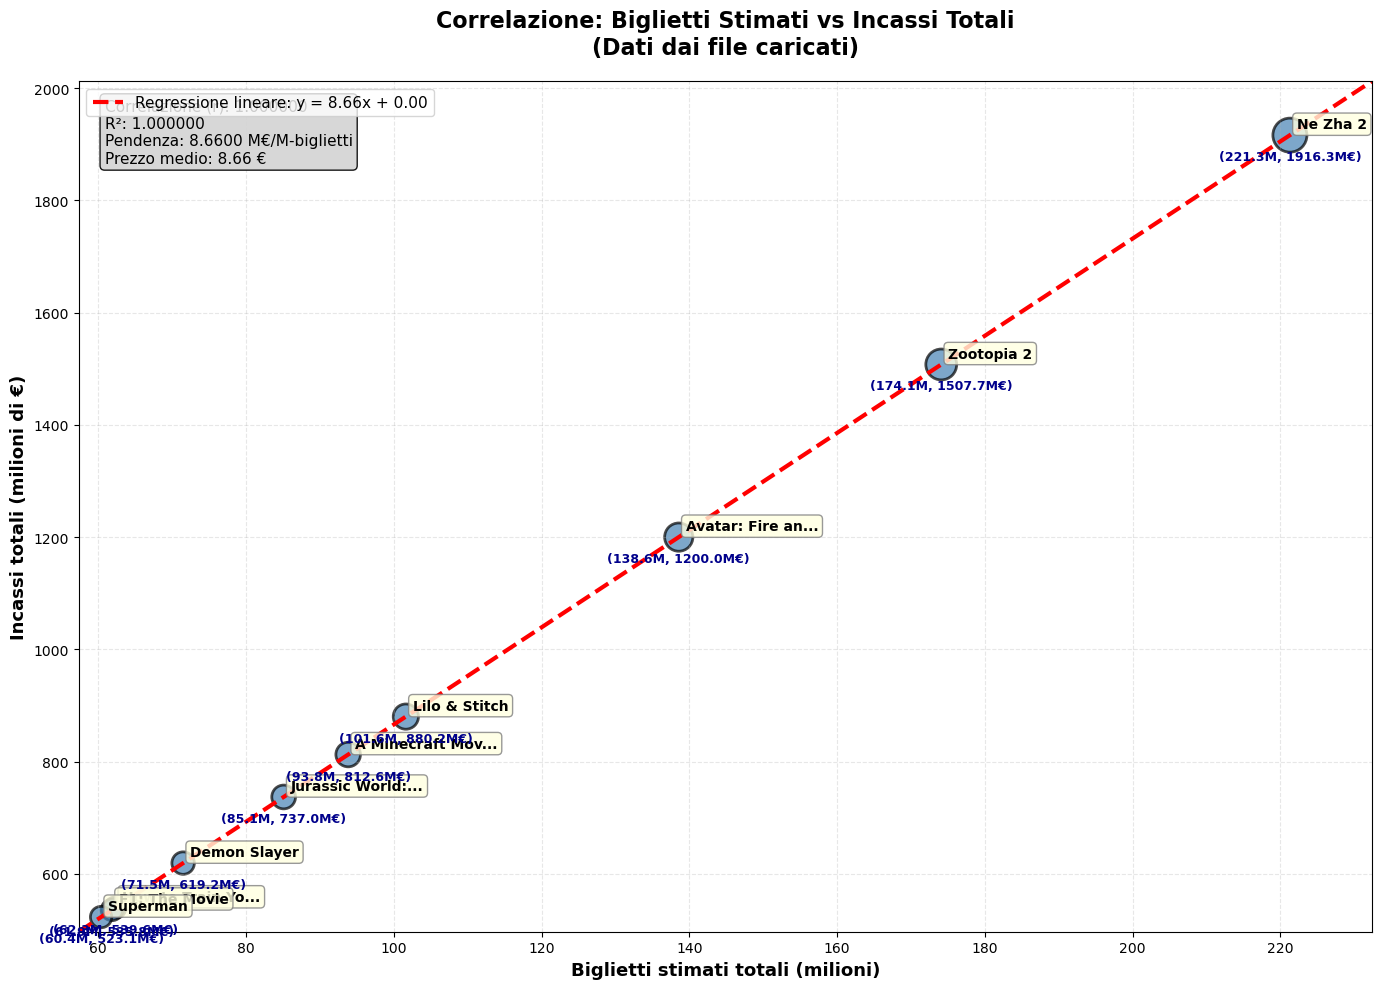

ANALISI CORRELAZIONE - DATI DAI FILE CARICATI
Film                      Biglietti (M)   Incassi (M€)    €/Biglietto  Prezzo vs Media
-------------------------------------------------------------------------------------
Ne Zha 2                  221.28          1916.28         8.66         0.0           %
Zootopia 2                174.10          1507.67         8.66         0.0           %
Avatar: Fire and Ash      138.57          1200.04         8.66         0.0           %
Lilo & Stitch             101.64          880.23          8.66         0.0           %
A Minecraft Movie         93.83           812.61          8.66         0.0           %
Jurassic World: Rebirth   85.11           737.02          8.66         0.0           %
Demon Slayer              71.50           619.20          8.66         0.0           %
How to Train Your Dragon  62.31           539.61          8.66         0.0           %
F1: The Movie             61.87           535.79          8.66         0.0           

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Caricamento dei dati dai file
incassi_df = pd.read_csv('IncassiTot.csv', thousands=',')
prezzi_df = pd.read_csv('PrezzoMedioTickets.csv')

# Pulizia dei dati incassi
incassi_df.columns = incassi_df.columns.str.strip()
incassi_df = incassi_df[['Nome del film', 'Incassi (in euro)']]

# Prepara i dati dei prezzi
prezzi_per_paese = {}
for col in prezzi_df.columns:
    valore_str = str(prezzi_df[col].iloc[0])
    valore_str_clean = valore_str.replace('eur', '').replace('€', '').strip()
    prezzi_per_paese[col] = float(valore_str_clean)

# Calcola la media dei prezzi per stimare i biglietti totali
prezzo_medio_globale = np.mean(list(prezzi_per_paese.values()))

# Calcola i biglietti stimati per ogni film
incassi_df['Biglietti stimati'] = incassi_df['Incassi (in euro)'] / prezzo_medio_globale

# Converti in milioni per una migliore leggibilità
incassi_df['Biglietti stimati (milioni)'] = incassi_df['Biglietti stimati'] / 1_000_000
incassi_df['Incassi (milioni di €)'] = incassi_df['Incassi (in euro)'] / 1_000_000

# Prepara i dati per il grafico
x = incassi_df['Biglietti stimati (milioni)']
y = incassi_df['Incassi (milioni di €)']

# Calcola la regressione lineare
coefficienti = np.polyfit(x, y, 1)
pendenza = coefficienti[0]
intercetta = coefficienti[1]

# Calcola la correlazione
correlazione = np.corrcoef(x, y)[0, 1]

# Crea il grafico a dispersione
plt.figure(figsize=(14, 10))

# Punti scatter con dimensioni proporzionali agli incassi
sizes = (incassi_df['Incassi (milioni di €)'] / incassi_df['Incassi (milioni di €)'].max()) * 500 + 100
scatter = plt.scatter(x, y, s=sizes, alpha=0.7, 
                      c='steelblue', edgecolors='black', linewidth=2)

# Linea di regressione
x_line = np.array([x.min() * 0.95, x.max() * 1.05])
y_line = pendenza * x_line + intercetta
plt.plot(x_line, y_line, 'r--', linewidth=3, 
         label=f'Regressione lineare: y = {pendenza:.2f}x + {intercetta:.2f}')

# Annota ogni punto con il nome del film
for i, row in incassi_df.iterrows():
    film = row['Nome del film']
    xi = row['Biglietti stimati (milioni)']
    yi = row['Incassi (milioni di €)']
    
    # Tronca il nome del film se troppo lungo
    nome_display = film[:15] + ('...' if len(film) > 15 else '')
    
    # Posiziona l'annotazione in modo intelligente
    offset_x = 5
    offset_y = 5
    
    plt.annotate(nome_display, 
                (xi, yi),
                xytext=(offset_x, offset_y),
                textcoords='offset points',
                fontsize=10,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', 
                         facecolor='lightyellow', 
                         alpha=0.8,
                         edgecolor='gray'))

# Aggiungi etichette con valori
for i, row in incassi_df.iterrows():
    xi = row['Biglietti stimati (milioni)']
    yi = row['Incassi (milioni di €)']
    
    plt.annotate(f'({xi:.1f}M, {yi:.1f}M€)', 
                (xi, yi),
                xytext=(0, -18),  # Sotto il punto
                textcoords='offset points',
                fontsize=9,
                ha='center',
                color='darkblue',
                fontweight='bold')

# Titolo e labels
plt.title('Correlazione: Biglietti Stimati vs Incassi Totali\n(Dati dai file caricati)', 
          fontsize=16, fontweight='bold', pad=20)

plt.xlabel('Biglietti stimati totali (milioni)', fontsize=13, fontweight='bold')
plt.ylabel('Incassi totali (milioni di €)', fontsize=13, fontweight='bold')

# Griglia
plt.grid(True, alpha=0.3, linestyle='--')

# Legenda
plt.legend(fontsize=11, loc='upper left')

# Aggiungi informazioni statistiche
info_text = (f'Correlazione (r): {correlazione:.6f}\n'
             f'R²: {correlazione**2:.6f}\n'
             f'Pendenza: {pendenza:.4f} M€/M-biglietti\n'
             f'Prezzo medio: {prezzo_medio_globale:.2f} €')

plt.text(0.02, 0.98, info_text,
         transform=plt.gca().transAxes,
         fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.9))

# Imposta limiti degli assi con margini
plt.xlim(x.min() * 0.95, x.max() * 1.05)
plt.ylim(y.min() * 0.95, y.max() * 1.05)

plt.tight_layout()
plt.show()

# Stampa tabella dati dettagliata
print("="*100)
print("ANALISI CORRELAZIONE - DATI DAI FILE CARICATI")
print("="*100)
print(f"{'Film':<25} {'Biglietti (M)':<15} {'Incassi (M€)':<15} {'€/Biglietto':<12} {'Prezzo vs Media':<15}")
print("-" * 85)

# Ordina per biglietti decrescenti
incassi_df = incassi_df.sort_values('Biglietti stimati (milioni)', ascending=False)

for idx, row in incassi_df.iterrows():
    prezzo_effettivo = row['Incassi (in euro)'] / row['Biglietti stimati']
    diff_percentuale = ((prezzo_effettivo - prezzo_medio_globale) / prezzo_medio_globale) * 100
    segno = "+" if diff_percentuale > 0 else ""
    
    print(f"{row['Nome del film']:<25} "
          f"{row['Biglietti stimati (milioni)']:<15.2f} "
          f"{row['Incassi (milioni di €)']:<15.2f} "
          f"{prezzo_effettivo:<12.2f} "
          f"{segno}{diff_percentuale:<14.1f}%")

print("-" * 85)
print(f"{'MEDIA':<25} "
      f"{incassi_df['Biglietti stimati (milioni)'].mean():<15.2f} "
      f"{incassi_df['Incassi (milioni di €)'].mean():<15.2f} "
      f"{prezzo_medio_globale:<12.2f} "
      f"{'0.0':<15}%")

print("\n" + "="*100)
print("RIEPILOGO STATISTICO:")
print(f"Correlazione lineare: {correlazione:.6f}")
print(f"R² (coefficiente di determinazione): {correlazione**2:.6f}")
print(f"Equazione regressione: y = {pendenza:.4f}x + {intercetta:.2f}")
print(f"Prezzo medio globale: {prezzo_medio_globale:.2f} €")
print(f"Intercetta: {intercetta:.2f} M€")
print("="*100)